photo_crop: 1163×711
svg_mask area:   13992
drawn_mask area: 231031


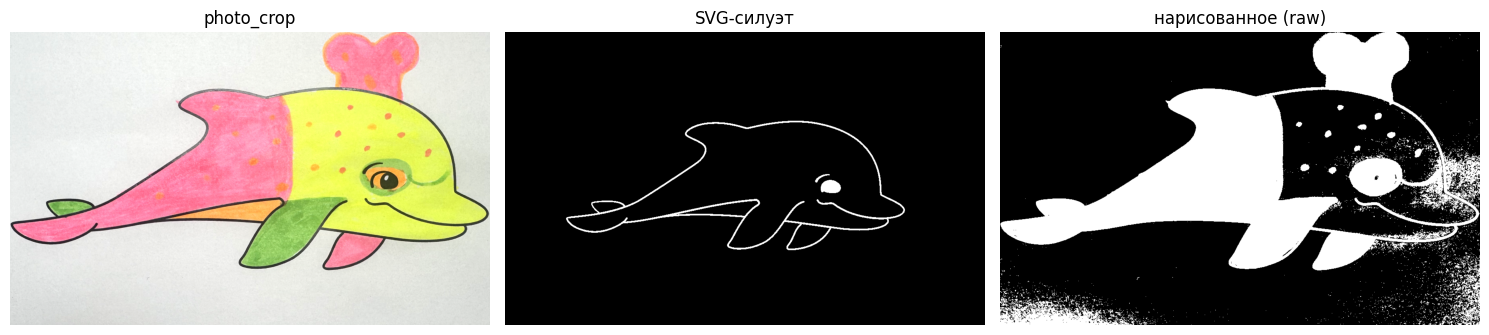

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")  # utils.py и svg.py лежат рядом

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from utils import detect_and_align, correct_photo, template_meta, image_rect_from_svg
from svg import SvgCharacter

# --- конфиг ---
CHAR_ID = "004"
CHAR_DIR = f"templates/{CHAR_ID}"
SVG_PATH = f"{CHAR_DIR}/mask.svg"
PHOTO_PATH = f"input/{CHAR_ID}_test3.HEIC"

CANVAS_SIZE = (1240, 1754)
MARKER_PX, MARGIN, CONTENT_PAD = 80, 60, 10
CONTENT_SCALE = 0.8

# --- geom + align (повторяем из основного ноутбука, чтобы быть автономным) ---
meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
image_rect = image_rect_from_svg(SVG_PATH, meta, content_scale=CONTENT_SCALE)

aligned = detect_and_align(PHOTO_PATH, meta)["aligned"]
aligned_corrected, _ = correct_photo(aligned, image_rect, meta)

ix, iy, iw, ih = image_rect
photo_crop = aligned_corrected[iy:iy+ih, ix:ix+iw]

# --- две маски ---
# SVG: всё непрозрачное
svg_ref = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="transparent")
svg_mask = (svg_ref[..., 3] > 128).astype(np.uint8) * 255

# Drawn: не-белые пиксели на фото
gray = cv2.cvtColor(photo_crop, cv2.COLOR_BGR2GRAY)
drawn_mask = (gray < 220).astype(np.uint8) * 255

print(f"photo_crop: {iw}×{ih}")
print(f"svg_mask area:   {(svg_mask>0).sum()}")
print(f"drawn_mask area: {(drawn_mask>0).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB))
axes[0].set_title("photo_crop"); axes[0].axis("off")
axes[1].imshow(svg_mask, cmap="gray")
axes[1].set_title("SVG-силуэт"); axes[1].axis("off")
axes[2].imshow(drawn_mask, cmap="gray")
axes[2].set_title("нарисованное (raw)"); axes[2].axis("off")
plt.tight_layout(); plt.show()


svg_mask area:   137459
drawn_mask area: 304530


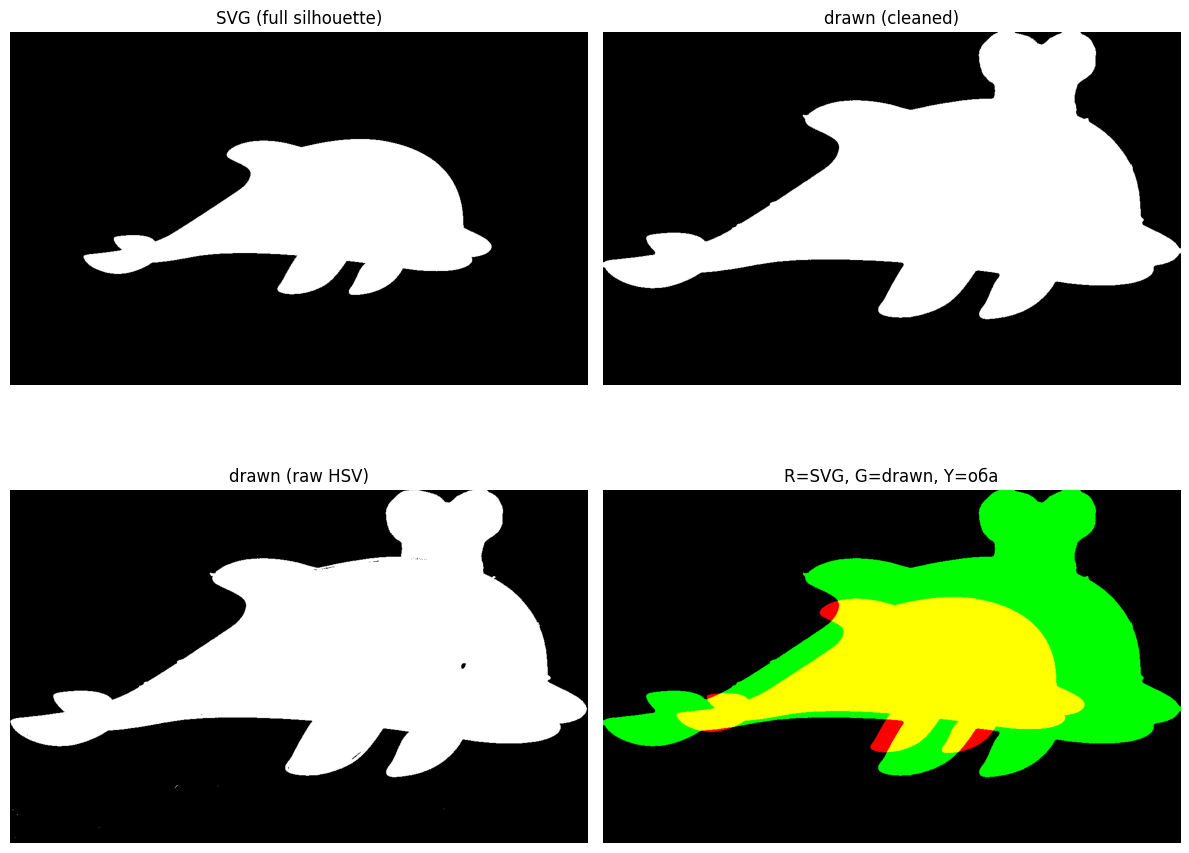

In [4]:
# --- SVG: полный силуэт (контур + заливки) ---
svg_full = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="white")
svg_mask = (svg_full[..., 3] > 128).astype(np.uint8) * 255

# --- Drawn: цветные + тёмные пиксели через HSV ---
hsv = cv2.cvtColor(photo_crop, cv2.COLOR_BGR2HSV)
s, v = hsv[..., 1], hsv[..., 2]
# либо насыщенный (цвет), либо тёмный (контур); исключаем яркую бумагу
drawn_raw = ((s > 40) | (v < 200)).astype(np.uint8) * 255

# закрываем мелкие дыры + крупнейшая компонента
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
drawn_closed = cv2.morphologyEx(drawn_raw, cv2.MORPH_CLOSE, k)
n_cc, labels, stats, _ = cv2.connectedComponentsWithStats((drawn_closed > 0).astype(np.uint8))
if n_cc > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    drawn_mask = ((labels == largest).astype(np.uint8)) * 255
else:
    drawn_mask = drawn_closed

print(f"svg_mask area:   {(svg_mask>0).sum()}")
print(f"drawn_mask area: {(drawn_mask>0).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(svg_mask, cmap="gray"); axes[0, 0].set_title("SVG (full silhouette)")
axes[0, 1].imshow(drawn_mask, cmap="gray"); axes[0, 1].set_title("drawn (cleaned)")
axes[1, 0].imshow(drawn_raw, cmap="gray"); axes[1, 0].set_title("drawn (raw HSV)")
# RGB-overlay для сравнения форм
overlay = np.zeros((ih, iw, 3), dtype=np.uint8)
overlay[..., 0] = svg_mask      # R = SVG
overlay[..., 1] = drawn_mask    # G = drawn
axes[1, 1].imshow(overlay); axes[1, 1].set_title("R=SVG, G=drawn, Y=оба")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()


In [5]:
def centroid_area(mask_bin):
    m = cv2.moments(mask_bin.astype(np.uint8))
    return m["m10"]/m["m00"], m["m01"]/m["m00"], m["m00"]

svg_bin = (svg_mask > 0).astype(np.uint8)
drawn_bin = (drawn_mask > 0).astype(np.uint8)

svg_cx, svg_cy, svg_area = centroid_area(svg_bin)
dr_cx, dr_cy, dr_area = centroid_area(drawn_bin)

# scale = во сколько раз сжать drawn, чтобы площадь совпала с svg
scale = np.sqrt(svg_area / dr_area)

# matrix: x' = scale*x + tx  (чтобы dr_centroid попал в svg_centroid после масштабирования)
M = np.float32([
    [scale, 0, svg_cx - scale * dr_cx],
    [0, scale, svg_cy - scale * dr_cy],
])

drawn_aligned = cv2.warpAffine(drawn_bin, M, (iw, ih), flags=cv2.INTER_NEAREST)

# IoU до/после
iou_before = (svg_bin & drawn_bin).sum() / max(1, (svg_bin | drawn_bin).sum())
iou_after  = (svg_bin & drawn_aligned).sum() / max(1, (svg_bin | drawn_aligned).sum())

print(f"scale = {scale:.4f}")
print(f"dx = {M[0,2]:.1f}, dy = {M[1,2]:.1f}")
print(f"IoU: {iou_before:.3f}  →  {iou_after:.3f}")


scale = 0.6718
dx = 160.0, dy = 151.4
IoU: 0.428  →  0.749


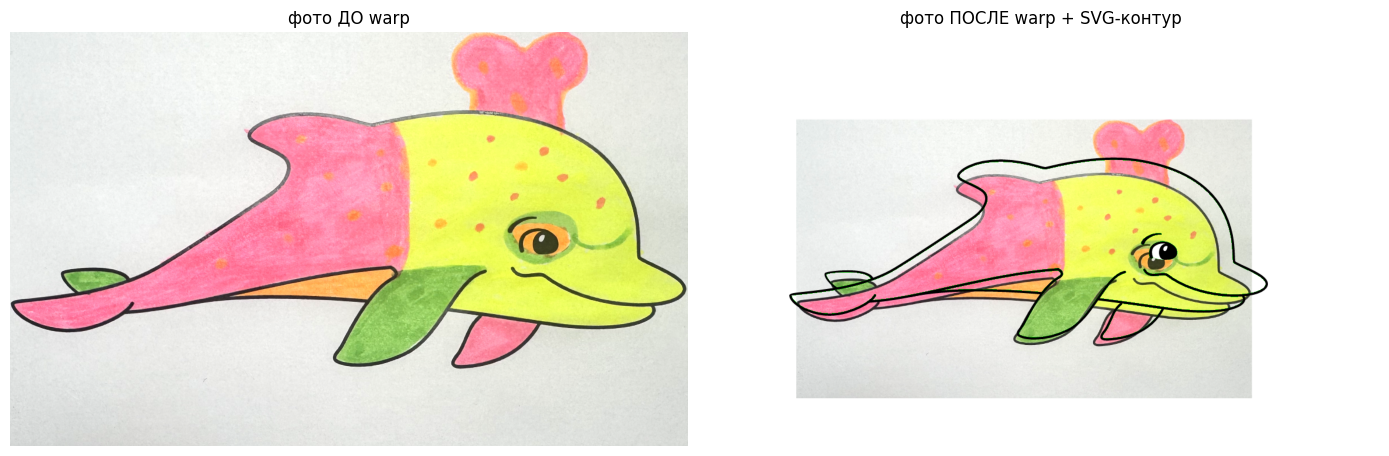

In [6]:
# применяем M к фото — теперь нарисованный совпадает с SVG
photo_aligned = cv2.warpAffine(photo_crop, M, (iw, ih), borderValue=(255, 255, 255))

# диагностика — SVG-контур поверх выровненного фото
svg_contour = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="transparent")
alpha_c = svg_contour[..., 3:4] / 255.0
overlay = (photo_aligned * (1 - alpha_c) + svg_contour[..., :3] * alpha_c).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB)); axes[0].set_title("фото ДО warp")
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[1].set_title("фото ПОСЛЕ warp + SVG-контур")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


Сохранено: output/004_aligned_hi.png (4226×2256)


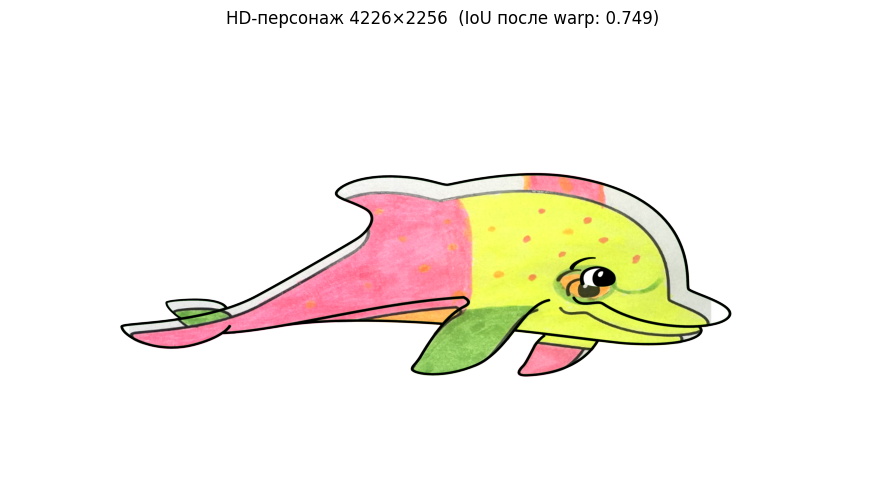

In [7]:
from utils import SvgCharacter

TARGET_W, TARGET_H = 4226, 2256

# 1) SVG рендерим в натуральном аспекте при нужном разрешении
render_h = TARGET_H
render_w = int(render_h * iw / ih)
svg_native = SvgCharacter(SVG_PATH).render(render_w, render_h, fill_zones="green")
svg_bgra = cv2.resize(svg_native, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

# 2) выровненное фото растягиваем под target
photo_hi = cv2.resize(photo_aligned, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

# 3) зелёные зоны SVG → цвет с фото, затем композит
b, g, r, a = svg_bgra[..., 0], svg_bgra[..., 1], svg_bgra[..., 2], svg_bgra[..., 3]
is_fill = (g > 200) & (r < 80) & (b < 80) & (a > 200)
svg_with_photo = svg_bgra.copy()
svg_with_photo[is_fill, :3] = photo_hi[is_fill]

alpha_f = svg_with_photo[..., 3:4].astype(np.float32) / 255.0
rgb = (svg_with_photo[..., :3].astype(np.float32) * alpha_f +
       photo_hi.astype(np.float32) * (1.0 - alpha_f)).astype(np.uint8)
colored_hi = cv2.merge([rgb[..., 0], rgb[..., 1], rgb[..., 2], svg_bgra[..., 3]])

# 4) сохранение + превью
Path("output").mkdir(exist_ok=True)
out_path = f"output/{CHAR_ID}_aligned_hi.png"
cv2.imwrite(out_path, colored_hi)
print(f"Сохранено: {out_path} ({colored_hi.shape[1]}×{colored_hi.shape[0]})")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(colored_hi, cv2.COLOR_BGRA2RGBA))
plt.axis("off"); plt.title(f"HD-персонаж {TARGET_W}×{TARGET_H}  (IoU после warp: {iou_after:.3f})")
plt.show()


iter 1 (dilate=60): IoU=0.874, scale=0.697, dx=151.5, dy=128.7
iter 2 (dilate=30): IoU=0.887, scale=0.700, dx=150.5, dy=126.2
iter 3 (dilate=15): IoU=0.895, scale=0.702, dx=149.8, dy=124.3


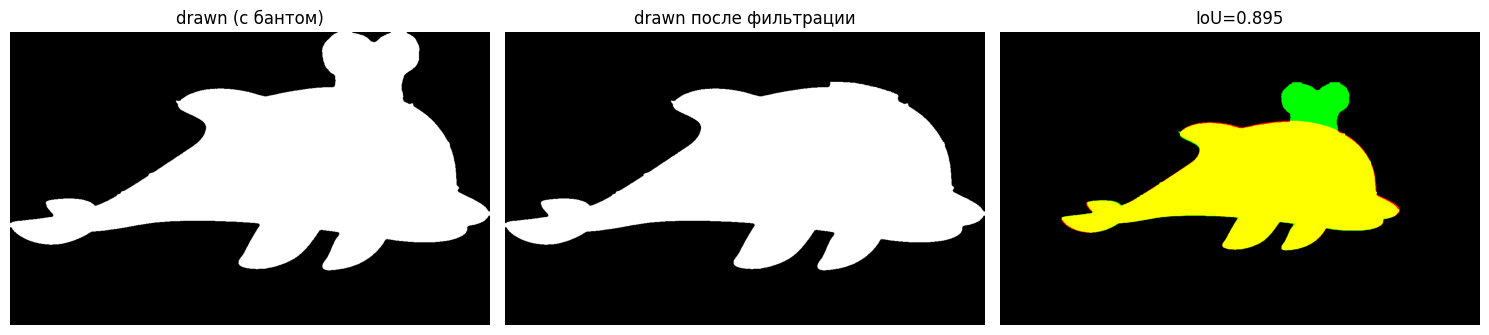

In [9]:
# --- итеративный refinement: отсекаем "лишние" части drawn ---
def refine_once(svg_bin, drawn_bin, M_prev, dilate_px=40):
    """Пересчитываем M, используя только ту часть drawn, которая близка к SVG
    после предыдущего warp."""
    # inverse warp: приводим svg_mask в систему координат drawn (до warp)
    M_inv = cv2.invertAffineTransform(M_prev)
    svg_in_drawn = cv2.warpAffine(svg_bin, M_inv, drawn_bin.shape[::-1], flags=cv2.INTER_NEAREST)
    # расширяем SVG-зону — всё, что снаружи, считаем "лишним"
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px, dilate_px))
    roi = cv2.dilate(svg_in_drawn, k)
    drawn_clean = drawn_bin & roi

    m_s = cv2.moments(svg_bin)
    m_d = cv2.moments(drawn_clean)
    sx, sy, sa = m_s["m10"]/m_s["m00"], m_s["m01"]/m_s["m00"], m_s["m00"]
    dx_, dy_, da = m_d["m10"]/m_d["m00"], m_d["m01"]/m_d["m00"], m_d["m00"]
    s = np.sqrt(sa / da)
    return np.float32([[s, 0, sx - s*dx_], [0, s, sy - s*dy_]]), drawn_clean

# 2 итерации обычно достаточно
M_refined = M.copy()
for i, dilate_px in enumerate([60, 30, 15]):  # от свободного к тугому
    M_refined, drawn_clean = refine_once(svg_bin, drawn_bin, M_refined, dilate_px=dilate_px)
    drawn_test = cv2.warpAffine(drawn_bin, M_refined, (iw, ih), flags=cv2.INTER_NEAREST)
    iou = (svg_bin & drawn_test).sum() / max(1, (svg_bin | drawn_test).sum())
    print(f"iter {i+1} (dilate={dilate_px}): IoU={iou:.3f}, scale={M_refined[0,0]:.3f}, dx={M_refined[0,2]:.1f}, dy={M_refined[1,2]:.1f}")

M = M_refined

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(drawn_bin, cmap="gray"); axes[0].set_title("drawn (с бантом)")
axes[1].imshow(drawn_clean, cmap="gray"); axes[1].set_title("drawn после фильтрации")
overlay = np.zeros((ih, iw, 3), dtype=np.uint8)
overlay[..., 0] = svg_bin * 255
overlay[..., 1] = drawn_test * 255
axes[2].imshow(overlay); axes[2].set_title(f"IoU={iou:.3f}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


In [10]:
drawn_clean_warped = cv2.warpAffine(drawn_clean, M_refined, (iw, ih), flags=cv2.INTER_NEAREST)
iou_body = (svg_bin & drawn_clean_warped).sum() / max(1, (svg_bin | drawn_clean_warped).sum())
print(f"IoU тела (без банта): {iou_body:.3f}")

IoU тела (без банта): 0.977


Сохранено: output/004_aligned_hi_v2.png (4226×2256)


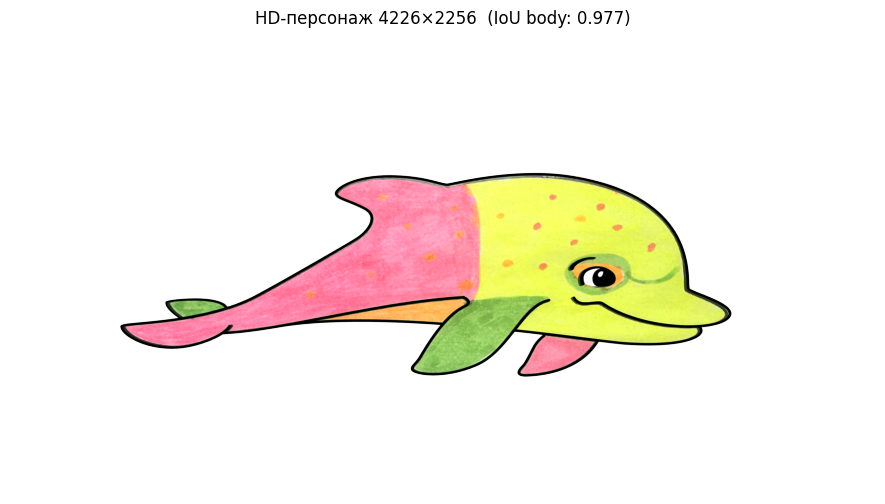

In [11]:
from utils import SvgCharacter

TARGET_W, TARGET_H = 4226, 2256

photo_aligned = cv2.warpAffine(photo_crop, M, (iw, ih), borderValue=(255, 255, 255))

render_h = TARGET_H
render_w = int(render_h * iw / ih)
svg_native = SvgCharacter(SVG_PATH).render(render_w, render_h, fill_zones="green")
svg_bgra = cv2.resize(svg_native, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

photo_hi = cv2.resize(photo_aligned, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

b, g, r, a = svg_bgra[..., 0], svg_bgra[..., 1], svg_bgra[..., 2], svg_bgra[..., 3]
is_fill = (g > 200) & (r < 80) & (b < 80) & (a > 200)
svg_with_photo = svg_bgra.copy()
svg_with_photo[is_fill, :3] = photo_hi[is_fill]

alpha_f = svg_with_photo[..., 3:4].astype(np.float32) / 255.0
rgb = (svg_with_photo[..., :3].astype(np.float32) * alpha_f +
       photo_hi.astype(np.float32) * (1.0 - alpha_f)).astype(np.uint8)
colored_hi = cv2.merge([rgb[..., 0], rgb[..., 1], rgb[..., 2], svg_bgra[..., 3]])

Path("output").mkdir(exist_ok=True)
out_path = f"output/{CHAR_ID}_aligned_hi_v2.png"
cv2.imwrite(out_path, colored_hi)
print(f"Сохранено: {out_path} ({colored_hi.shape[1]}×{colored_hi.shape[0]})")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(colored_hi, cv2.COLOR_BGRA2RGBA))
plt.axis("off"); plt.title(f"HD-персонаж {TARGET_W}×{TARGET_H}  (IoU body: {iou_body:.3f})")
plt.show()
